In [1]:
import torch
print(torch.cuda.is_available())   # should be True
print(torch.version.cuda)          # CUDA version PyTorch is built with
print(torch.cuda.get_device_name(0)) if torch.cuda.is_available() else None
print(torch.cuda.device_count())
import os
os.cpu_count()

True
11.7
NVIDIA RTX 6000 Ada Generation
2


48

In [2]:

from typing import Dict, Tuple, List, Optional
import numpy as np
import pandas as pd
import logging
logger = logging.getLogger(__name__)

def load_ap1_data_from_csv(csv_filepath: str, replicate: Optional[int] = None) -> Dict[str, np.ndarray]:
    """
    Loads AP1 single-cell data from CSV or Excel file.

    Args:
        csv_filepath: Path to the CSV or Excel file

    Returns:
        Dictionary with condition identifiers as keys and feature matrices as values
    """
    logger.info(f"Loading data from: {csv_filepath}")

    # Load the data based on file extension
    if csv_filepath.endswith('.csv'):
        df = pd.read_csv(csv_filepath)
    elif csv_filepath.endswith('.xlsx'):
        df = pd.read_excel(csv_filepath)
    else:
        raise ValueError("Unsupported file format. Please provide a .csv or .xlsx file.")
    
    replacement_map = {
                        '0.316 uM Vemurafenib': 'Vem',
                        '0.316 uM Vem + 0.0316 uM Tram': 'Vem+Tram'
                        }
    df['condition'] = df['condition'].replace(replacement_map)

    print(df['condition'].unique())

    # Define AP1 protein features (these are in log space already)
    ap1_features = [
        'cFOS (log a.u.)', 'p-cFOS (log a.u.)', 'FRA1 (log a.u.)', 'p-FRA1 (log a.u.)', 'FRA2 (log a.u.)',
        'cJUN (log a.u.)', 'p-cJUN (log a.u.)', 'JUNB (log a.u.)', 'JUND (log a.u.)', 'p-ATF1 (log a.u.)',
        'ATF2 (log a.u.)',	 'p-ATF2 (log a.u.)', 'ATF3 (log a.u.)', 'ATF4 (log a.u.)', 'p-ATF4 (log a.u.)',
        'ATF5 (log a.u.)', 'ATF6 (log a.u.)', 'MITF (log a.u.)', 'NGFR (log a.u.)', 'p-ERK (log a.u.)',
    ]

    # Check if all features exist
    missing_features = [f for f in ap1_features if f not in df.columns]
    if missing_features:
        logger.warning(f"Missing features: {missing_features}")
        ap1_features = [f for f in ap1_features if f in df.columns]

    logger.info(f"Using {len(ap1_features)} AP1 features")

    # Create condition-based data dictionary
    data_dict = {}

    if replicate is not None:
        # Group by condition, time, and cell line
        for (condition, time, cell_line, replicate_id), group in df.groupby(['condition', 'time', 'cell_line', 'replicate_id']):
            # Create condition identifier
            condition_id = f"{cell_line}_{condition}_{time.replace(' ', '')}_rep{replicate_id}"

            # Extract feature matrix
            feature_matrix = group[ap1_features].values

            # Remove rows with any NaN values
            valid_rows = ~np.isnan(feature_matrix).any(axis=1)
            feature_matrix = feature_matrix[valid_rows]

            if len(feature_matrix) > 0:
                data_dict[condition_id] = feature_matrix
                logger.info(f"Loaded {condition_id}: {feature_matrix.shape}")
            else:
                logger.warning(f"No valid data for {condition_id}")
    else:
        # Group by condition, time, and cell line
        for (condition, time, cell_line), group in df.groupby(['condition', 'time', 'cell_line']):
            # Create condition identifier
            condition_id = f"{cell_line}_{condition}_{time.replace(' ', '')}"

            # Extract feature matrix
            feature_matrix = group[ap1_features].values

            # Remove rows with any NaN values
            valid_rows = ~np.isnan(feature_matrix).any(axis=1)
            feature_matrix = feature_matrix[valid_rows]

            if len(feature_matrix) > 0:
                data_dict[condition_id] = feature_matrix
                logger.info(f"Loaded {condition_id}: {feature_matrix.shape}")
            else:
                logger.warning(f"No valid data for {condition_id}")

    return data_dict

def prepare_pair_from_mat(cell_line: str,
                          baseline_condition: str, baseline_time: str,
                          target_condition: str, target_time: str,
                          replicate: Optional[int] = None) -> Tuple[np.ndarray, np.ndarray]:
    print("Cell line: ", cell_line)
    raw_data_dict = load_ap1_data_from_csv('mmc5.xlsx', replicate)

    if replicate is not None:
        pre_key = f"{cell_line}_{baseline_condition}_{baseline_time}_rep{replicate}"
        post_key = f"{cell_line}_{target_condition}_{target_time}_rep{replicate}"
    else:
        pre_key = f"{cell_line}_{baseline_condition}_{baseline_time}"
        post_key = f"{cell_line}_{target_condition}_{target_time}"

    if pre_key not in raw_data_dict or post_key not in raw_data_dict:
        raise ValueError(f"Pair not found: {pre_key}, {post_key}")

    # Equalize N
    n = min(len(raw_data_dict[pre_key]), len(raw_data_dict[post_key]))
    X_pre_raw = raw_data_dict[pre_key][:n]
    X_post_raw = raw_data_dict[post_key][:n]
    return X_pre_raw, X_post_raw



In [3]:
import os
import sys
import json
import logging
import argparse
import geomloss
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Dict, Tuple, List, Optional
from umap import UMAP
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics.pairwise import rbf_kernel
from typing import Dict, Tuple, List
from scipy.stats import ks_2samp
from scipy.spatial.distance import cdist
from sklearn.metrics import r2_score

import gc
gc.collect()

def median_heuristic_gamma(X: np.ndarray, Y: np.ndarray) -> float:
    """
    Median heuristic for RBF bandwidth: gamma = 1 / median(||x - y||^2).
    Uses the median of pairwise distances in the pooled set.
    """
    Z = np.vstack([X, Y])
    # Sample if too large for efficiency
    max_samples = 5000
    if Z.shape[0] > max_samples:
        idx = np.random.choice(Z.shape[0], size=max_samples, replace=False)
        Z = Z[idx]
    D2 = cdist(Z, Z, metric='sqeuclidean')
    # Use upper triangular without diagonal
    triu = D2[np.triu_indices_from(D2, k=1)]
    med = np.median(triu[triu > 0]) if np.any(triu > 0) else 1.0
    return 1.0 / max(med, 1e-12)

def mmd_distance(X: np.ndarray, Y: np.ndarray, gamma: float) -> float:
    """
    Unbiased MMD^2 estimator using Gaussian (RBF) kernel, sklearn backend.

    Args:
        X: (n_samples, n_features) first sample
        Y: (m_samples, n_features) second sample
        gamma: RBF kernel bandwidth; if None, uses median heuristic

    Returns:
        Unbiased MMD^2 value
    """
    n = X.shape[0]
    m = Y.shape[0]

    # Kernel matrices
    Kxx = rbf_kernel(X, X, gamma=gamma)
    Kyy = rbf_kernel(Y, Y, gamma=gamma)
    Kxy = rbf_kernel(X, Y, gamma=gamma)

    # Unbiased: exclude diagonal entries
    np.fill_diagonal(Kxx, 0.0)
    np.fill_diagonal(Kyy, 0.0)

    term_xx = Kxx.sum() / (n * (n - 1)) if n > 1 else 0.0
    term_yy = Kyy.sum() / (m * (m - 1)) if m > 1 else 0.0
    term_xy = 2.0 * Kxy.mean()

    mmd2 = term_xx + term_yy - term_xy
    mmd2 = max(mmd2, 0.0)  # Numerical stability
    return float(mmd2)

def r2_feature_means(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """
    R^2 computed across features between mean vectors of y_true and y_pred.
    """
    mu_true = y_true.mean(axis=0)
    mu_pred = y_pred.mean(axis=0)
    ss_res = float(np.sum((mu_true - mu_pred) ** 2))
    ss_tot = float(np.sum((mu_true - mu_true.mean()) ** 2))
    if ss_tot <= 1e-12:
        return 1.0 if ss_res <= 1e-12 else 0.0
    return 1.0 - ss_res / ss_tot

def wasserstein_pointcloud(
    X,
    Y,
    p: int = 2,
    a=None,
    b=None,
    method: str = "emd",          # "emd" (exact) or "sinkhorn" (approx)
    reg: float = 1e-1,            # Sinkhorn regularization (only used if method="sinkhorn")
    return_plan: bool = False,
):
    """
    Compute Wasserstein distance W_p between two empirical distributions supported on point sets X and Y.

    Parameters
    ----------
    X : (n, d) array-like
        Source points.
    Y : (m, d) array-like
        Target points.
    p : int
        Order of the Wasserstein distance (commonly 1 or 2).
    a : (n,) array-like or None
        Weights for X; if None, uniform weights.
    b : (m,) array-like or None
        Weights for Y; if None, uniform weights.
    method : str
        "emd" for exact optimal transport (requires POT),
        "sinkhorn" for entropic approximation (requires POT).
    reg : float
        Entropic regularization strength for Sinkhorn.
    return_plan : bool
        If True, also return the optimal transport plan.

    Returns
    -------
    Wp : float
        Wasserstein distance of order p.
    plan : (n, m) ndarray, optional
        Optimal transport plan (only if return_plan=True).
    """
    X = np.asarray(X, dtype=np.float64)
    Y = np.asarray(Y, dtype=np.float64)
    if X.ndim != 2 or Y.ndim != 2:
        raise ValueError("X and Y must be 2D arrays with shape (n, d) and (m, d).")
    if X.shape[1] != Y.shape[1]:
        raise ValueError(f"Dimension mismatch: X has d={X.shape[1]}, Y has d={Y.shape[1]}.")

    n, d = X.shape
    m, _ = Y.shape

    if a is None:
        a = np.full(n, 1.0 / n, dtype=np.float64)
    else:
        a = np.asarray(a, dtype=np.float64)
        a = a / a.sum()

    if b is None:
        b = np.full(m, 1.0 / m, dtype=np.float64)
    else:
        b = np.asarray(b, dtype=np.float64)
        b = b / b.sum()

    # Cost matrix: C_ij = ||x_i - y_j||^p
    # Compute squared Euclidean via (x-y)^2 = x^2 + y^2 - 2xy for speed
    X2 = np.sum(X * X, axis=1, keepdims=True)          # (n, 1)
    Y2 = np.sum(Y * Y, axis=1, keepdims=True).T        # (1, m)
    sq = np.maximum(X2 + Y2 - 2.0 * (X @ Y.T), 0.0)     # (n, m)
    if p == 2:
        C = sq
    else:
        C = sq ** (p / 2.0)

    try:
        import ot  # POT: Python Optimal Transport
    except ImportError as e:
        raise ImportError(
            "This function requires the POT library. Install with: pip install pot"
        ) from e

    method = method.lower()
    if method == "emd":
        # exact OT: minimizes <P, C>
        P = ot.emd(a, b, C)
        cost = float(np.sum(P * C))
    elif method == "sinkhorn":
        # entropic OT approximation
        P = ot.sinkhorn(a, b, C, reg=reg)
        cost = float(np.sum(P * C))
    else:
        raise ValueError('method must be either "emd" or "sinkhorn".')

    Wp = cost ** (1.0 / p)

    if return_plan:
        return Wp, P
    return Wp

def summarize_metrics(y_true: np.ndarray, y_pred: np.ndarray, median_gamma: float) -> dict:
    """
    Compute a standard set of metrics: MMD^2 (RBF), R^2 of feature means, median KS across features, and Wasserstein distance.
    """
    # Drop any samples that contain NaNs in either true or pred
    mask = (~np.isnan(y_true).any(axis=1)) & (~np.isnan(y_pred).any(axis=1))
    if mask.sum() < len(y_true):
        print(f"[summarize_metrics] Dropping {len(y_true) - mask.sum()} samples with NaNs.")
    
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    out = {}

    out['mmd2_gamma_median'] = mmd_distance(y_true, y_pred, gamma=median_gamma)
    out['mmd2_gamma_0.5'] = mmd_distance(y_true, y_pred, gamma=0.5)
    out['mmd2_gamma_1.0'] = mmd_distance(y_true, y_pred, gamma=1.0)
    out['wasserstein_distance'] = wasserstein_pointcloud(y_true, y_pred, p=2, method="emd")
    out['R2_feature_means'] = r2_feature_means(y_true, y_pred)
    return out

def split_train_test(X: np.ndarray, Y: np.ndarray, train_fraction: float, seed: int = 42) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    if X.shape[0] != Y.shape[0]:
        min_len = min(len(X), len(Y))
        X = X[:min_len]
        Y = Y[:min_len]

    n = X.shape[0]
    n_train = max(1, int(n * train_fraction))
    rng = np.random.default_rng(seed)
    idx = rng.permutation(n)
    tr_idx, te_idx = idx[:n_train], idx[n_train:]
    return X[tr_idx], X[te_idx], Y[tr_idx], Y[te_idx]

def topk_markers(adata, drug: str, k: int = 50, rank_key: str = "marker_genes-drug-rank"):
    R = adata.varm[rank_key]

    # --- get the rank vector for this drug ---
    if hasattr(R, "columns") and hasattr(R, "iloc"):  # pandas DataFrame
        if drug in R.columns:
            r = R[drug].to_numpy()
        else:
            # fallback: interpret columns as ordered groups; try to map via rank_genes_groups names
            names = adata.uns["rank_genes_groups"]["names"]
            groups = list(names.dtype.names) if (hasattr(names, "dtype") and names.dtype.names is not None) else list(names.columns)
            r = R.iloc[:, groups.index(drug)].to_numpy()
    else:  # numpy array (or array-like)
        names = adata.uns["rank_genes_groups"]["names"]
        groups = list(names.dtype.names) if (hasattr(names, "dtype") and names.dtype.names is not None) else list(names.columns)
        r = np.asarray(R)[:, groups.index(drug)]

    # smaller rank => stronger marker
    idx = np.argsort(r)[:k]
    gene_ids = adata.var_names[idx].to_list()
    gene_short = (adata.var.iloc[idx]["gene_short_name"].to_list()
                  if "gene_short_name" in adata.var.columns else None)
    return gene_ids, gene_short, idx


In [4]:
import sys
import torch
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from cellot.models.cellot import load_networks, compute_loss_f, compute_loss_g

from sklearn.metrics.pairwise import rbf_kernel


def mmd_distance(x, y, gamma):
    xx = rbf_kernel(x, x, gamma)
    xy = rbf_kernel(x, y, gamma)
    yy = rbf_kernel(y, y, gamma)

    return xx.mean() + yy.mean() - 2 * xy.mean()

def compute_mmd_loss(lhs, rhs, gammas):
    return np.mean([mmd_distance(lhs, rhs, g) for g in gammas])

from cellot.losses.mmd import mmd_distance

def run_cellot_pair(train_pre: np.ndarray, train_post: np.ndarray,
                    test_pre: np.ndarray, test_post: np.ndarray,
                    layers: Optional[List[int]] = [64, 64, 64, 64],
                    n_epochs: int = 5000,
                    feature_subset: Optional[List[int]] = None,) -> Dict:
    
    device = 'cuda'
    print(f"VERS torch={torch.__version__} (CellOT), device={device}", file=sys.stderr, flush=True)


    # Apply feature subset if specified
    if feature_subset is not None:
        print(f"Using feature subset of size {len(feature_subset)}", file=sys.stderr, flush=True)
        train_pre = train_pre[:, feature_subset]
        train_post = train_post[:, feature_subset]
        test_pre = test_pre[:, feature_subset]
        test_post = test_post[:, feature_subset]

    # Preprocess: standardize jointly and optionally apply PCA for stability
    X_all = np.vstack([train_pre, train_post])
    scaler = StandardScaler()
    X_all_s = scaler.fit_transform(X_all)
    d = X_all_s.shape[1]
    pca_dims = min(50, d)
    if pca_dims < d:
        pca = PCA(n_components=pca_dims, svd_solver='full', random_state=42)
        X_all_p = pca.fit_transform(X_all_s)
        tr_pre_p = X_all_p[:len(train_pre)]
        tr_post_p = X_all_p[len(train_pre):]
        te_pre_p = pca.transform(scaler.transform(test_pre))
        use_pca = True
    else:
        tr_pre_p = X_all_s[:len(train_pre)]
        tr_post_p = X_all_s[len(train_pre):]
        te_pre_p = scaler.transform(test_pre)
        use_pca = False

    # Networks - Using official CellOT configuration
    input_dim = tr_pre_p.shape[1]
    config = {
        'model': {
            'name': 'cellot',
            'hidden_units': layers,
            'kernel_init_fxn': {'name': 'uniform', 'a': -0.01, 'b': 0.01},
            'activation': 'relu',
            'softplus_W_kernels': True,
            'f': {},
            'g': {}
        }
    }
    f, g = load_networks(config, input_dim=input_dim)
    f = f.to(device).float()
    g = g.to(device).float()

    # Data tensors
    src = torch.tensor(tr_pre_p, dtype=torch.float32, device=device)
    tgt = torch.tensor(tr_post_p, dtype=torch.float32, device=device)
    te_src = torch.tensor(te_pre_p, dtype=torch.float32, device=device)

    # Optimizers matching official config
    lr = 1e-4
    optim_f = torch.optim.Adam(f.parameters(), lr=lr, betas=(0.5, 0.9), weight_decay=0)
    optim_g = torch.optim.Adam(g.parameters(), lr=lr, betas=(0.5, 0.9), weight_decay=0)

    # No schedulers in official config
    # n_epochs = 1200  # More epochs for better convergence
    n_epochs = n_epochs + 1  
    # Training loop following official CellOT implementation
    f.train(); g.train()
    batch_size = 256  # Official config
    n_inner_iters = 10  # Official config


    for epoch in range(n_epochs):
        f.train(); g.train()
        perm_t = torch.randperm(len(tgt), device=device)[:batch_size]
        yt = tgt[perm_t]
        
        # Multiple g updates per iteration (official implementation)
        for _ in range(n_inner_iters):
            perm_s = torch.randperm(len(src), device=device)[:batch_size]
            xs = src[perm_s].detach().clone().requires_grad_(True)
            
            optim_g.zero_grad()
            g_loss = compute_loss_g(f, g, xs).mean()
            g_loss.backward()
            torch.nn.utils.clip_grad_norm_(g.parameters(), max_norm=0.5)
            optim_g.step()
        
        # Single f update (official implementation)
        perm_s = torch.randperm(len(src), device=device)[:batch_size]
        xs = src[perm_s].detach().clone().requires_grad_(True)
        
        optim_f.zero_grad()
        f_loss = compute_loss_f(f, g, xs, yt).mean()
        f_loss.backward()
        optim_f.step()
        
        # Clamp weights for f (official implementation)
        if hasattr(f, 'clamp_w'):
            f.clamp_w()
        
        
        # ---- Evaluate train MMD and early-stop ----
        if epoch % 50 == 0: 
            f.eval()
            g.eval()


            # Transport a fixed subset of training PRE (in preprocessed space)
            tr_src_eval = src.requires_grad_(True)
            tr_pred_p = g.transport(tr_src_eval).detach().cpu().numpy()
            # Invert preprocessing to original space (so MMD is comparable to your final eval)
            if use_pca:
                tr_pred = scaler.inverse_transform(pca.inverse_transform(tr_pred_p))
            else:
                tr_pred = scaler.inverse_transform(tr_pred_p)
            train_mmd_min = mmd_distance(train_post, tr_pred, gamma=1.0)


            te_src_full = te_src.detach().clone().requires_grad_(True)
            te_pred_full = g.transport(te_src_full).detach().cpu().numpy()
            if use_pca:
                te_pred_inv_full = scaler.inverse_transform(pca.inverse_transform(te_pred_full))
            else:
                te_pred_inv_full = scaler.inverse_transform(te_pred_full)
            test_metrics = mmd_distance(test_post, te_pred_inv_full, gamma=median_gamma)

            print(
                f"[CellOT] epoch={epoch} f_loss={f_loss.item():.4f} g_loss={g_loss.item():.4f} | "
                f"train mmd={train_mmd_min:.4f} | "
                f"test_mmd={test_metrics:.4f}",
                file=sys.stderr,
                flush=True,
            )

                
            

    # Inference (CellOT transport requires gradients for autodiff)
    f.eval(); g.eval()
    # CellOT needs gradients even in eval mode for transport computation
    te_src_for_transport = te_src.detach().clone().requires_grad_(True)
    te_tx = g.transport(te_src_for_transport).detach().cpu().numpy()

    # Inverse preprocess
    if use_pca:
        te_tx_inv = scaler.inverse_transform(pca.inverse_transform(te_tx))
    else:
        te_tx_inv = scaler.inverse_transform(te_tx)
    # Final evaluation
    metrics = summarize_metrics(test_post[:len(te_tx_inv)], te_tx_inv, median_gamma)

    gammas = np.logspace(1, -3, num=50)
    mmd = compute_mmd_loss(test_post[:len(te_tx_inv)], te_tx_inv, gammas=gammas)
    print(f"[CellOT] Final CellOT MMD: {mmd:.4f}", file=sys.stderr, flush=True)
    
    return {'y_pred': te_tx_inv, 'metrics': metrics}
    


Cell line:  COLO858
['DMSO' 'Vem' 'Vem+Tram']
Cell line:  WM902B
['DMSO' 'Vem' 'Vem+Tram']
Cell line:  RVH421
['DMSO' 'Vem' 'Vem+Tram']
Cell line:  SKMEL19
['DMSO' 'Vem' 'Vem+Tram']
(8887, 20)
(3026, 20)
(8887, 20)
(3026, 20)


VERS torch=1.13.1+cu117 (CellOT), device=cuda


Median heuristic gamma: 0.06507182537652856
**************** Run: 0 ****************


[CellOT] epoch=0 f_loss=-4516089.0000 g_loss=5721527.0000 | train mmd=0.1188 | test_mmd=0.7641
[CellOT] epoch=50 f_loss=-193.3354 g_loss=210.4248 | train mmd=0.6200 | test_mmd=0.5751
[CellOT] epoch=100 f_loss=-242.0757 g_loss=318.8307 | train mmd=0.7941 | test_mmd=0.5801
[CellOT] epoch=150 f_loss=-517.4467 g_loss=447.1668 | train mmd=0.6577 | test_mmd=0.4198
[CellOT] epoch=200 f_loss=-568.7064 g_loss=624.2546 | train mmd=0.7547 | test_mmd=0.5217
[CellOT] epoch=250 f_loss=-618.2043 g_loss=1247.5505 | train mmd=0.5924 | test_mmd=0.5078
[CellOT] epoch=300 f_loss=-751.1533 g_loss=858.7312 | train mmd=0.6003 | test_mmd=0.4075
[CellOT] epoch=350 f_loss=-1879.7166 g_loss=8723.2227 | train mmd=0.2504 | test_mmd=0.3555
[CellOT] epoch=400 f_loss=-791.8365 g_loss=1815.0492 | train mmd=0.5694 | test_mmd=0.4060
[CellOT] epoch=450 f_loss=-990.6674 g_loss=1094.6027 | train mmd=0.6114 | test_mmd=0.4358
[CellOT] epoch=500 f_loss=-961.6943 g_loss=1525.3376 | train mmd=0.5552 | test_mmd=0.2959
[CellOT] e

Run 0 metrics: {'mmd2_gamma_median': 0.15907008564668623, 'mmd2_gamma_0.5': 0.37413960325160184, 'mmd2_gamma_1.0': 0.3602064540216096, 'wasserstein_distance': 4.494267324933481, 'R2_feature_means': 0.6873727078669087}
**************** Run: 1 ****************


...

Run 8 metrics: {'mmd2_gamma_median': 0.19839329483775225, 'mmd2_gamma_0.5': 0.43438770441311, 'mmd2_gamma_1.0': 0.4040646845583209, 'wasserstein_distance': 7.975075909833901, 'R2_feature_means': 0.5820211268185805}
**************** Run: 9 ****************


[CellOT] epoch=0 f_loss=-2810028.7500 g_loss=3146197.0000 | train mmd=0.1188 | test_mmd=0.7641
[CellOT] epoch=50 f_loss=400.1102 g_loss=729.1108 | train mmd=0.7505 | test_mmd=0.5602
[CellOT] epoch=100 f_loss=-290.5743 g_loss=335.8873 | train mmd=0.8186 | test_mmd=0.5489
[CellOT] epoch=150 f_loss=-473.4167 g_loss=503.5609 | train mmd=0.7760 | test_mmd=0.5259
[CellOT] epoch=200 f_loss=-738.4655 g_loss=670.5363 | train mmd=0.5159 | test_mmd=0.2290
[CellOT] epoch=250 f_loss=-4800.0015 g_loss=1666.9025 | train mmd=0.5974 | test_mmd=0.6816
[CellOT] epoch=300 f_loss=-8798.2188 g_loss=1573.6814 | train mmd=0.6242 | test_mmd=0.6291
[CellOT] epoch=350 f_loss=-4800.9004 g_loss=1582.6705 | train mmd=0.6803 | test_mmd=0.4331
[CellOT] epoch=400 f_loss=-22103.8594 g_loss=4155.9644 | train mmd=0.5362 | test_mmd=0.4304
[CellOT] epoch=450 f_loss=-887.7590 g_loss=2170.2063 | train mmd=0.7173 | test_mmd=0.4232
[CellOT] epoch=500 f_loss=-97252.9062 g_loss=20646.4160 | train mmd=0.6141 | test_mmd=0.4283
[Ce

Run 9 metrics: {'mmd2_gamma_median': 0.11818534639959144, 'mmd2_gamma_0.5': 0.3237851355599382, 'mmd2_gamma_1.0': 0.3530427338917192, 'wasserstein_distance': 9.418764747466792, 'R2_feature_means': 0.6073814574103589}
                        mean     std
mmd2_gamma_median     0.1581  0.0554
mmd2_gamma_0.5        0.4350  0.1312
mmd2_gamma_1.0        0.4497  0.1210
wasserstein_distance  6.8450  2.1506
R2_feature_means      0.6498  0.0861


/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


NameError: name 'drug' is not defined

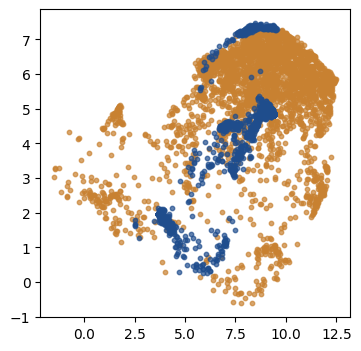

In [5]:
X_pre_COLO858, X_post_COLO858 = prepare_pair_from_mat('COLO858', 'DMSO','24h', 'Vem', '72h')
X_pre_WM902B, X_post_WM902B = prepare_pair_from_mat('WM902B', 'DMSO','24h', 'Vem', '72h')
X_pre_RVH421, X_post_RVH421 = prepare_pair_from_mat('RVH421', 'DMSO','24h', 'Vem', '72h')
X_pre_SKMEL19, X_post_SKMEL19 = prepare_pair_from_mat('SKMEL19', 'DMSO','24h', 'Vem', '72h')

jfe_indices = [1, 6, 0, 5, 4, 7, 8, 2, 3, 19]

X_pre_combined = np.concatenate([X_pre_WM902B, X_pre_RVH421, X_pre_SKMEL19], axis=0)
X_post_combined = np.concatenate([X_post_WM902B, X_post_RVH421, X_post_SKMEL19], axis=0)


X_tr_pre = X_pre_combined
Y_tr_post = X_post_combined
X_te_pre = X_pre_COLO858
Y_te_post = X_post_COLO858

print(X_tr_pre.shape)
print(X_te_pre.shape)
print(Y_tr_post.shape)
print(Y_te_post.shape)
# Compute median heuristic gamma on training data
median_gamma = median_heuristic_gamma(X_tr_pre, Y_tr_post)
print("Median heuristic gamma:", median_gamma)


all_metrics = []
for run in range(10):
    print(f"**************** Run: {run} ****************")
    seed = 1234 + run
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    out = run_cellot_pair(X_tr_pre[:, jfe_indices], Y_tr_post[:, jfe_indices], X_te_pre[:, jfe_indices], Y_te_post[:, jfe_indices], n_epochs=1000)
    metrics = summarize_metrics(out["y_pred"], Y_te_post[:, jfe_indices], median_gamma)
    print(f"Run {run} metrics: {metrics}")
    all_metrics.append(metrics)

# Results summary
df = pd.DataFrame(all_metrics)
print(df.describe().T[['mean', 'std']].round(4))


from umap import UMAP
import matplotlib.pyplot as plt

source = Y_tr_post[:, jfe_indices]
target = Y_te_post[:, jfe_indices]
predicted = out.get('y_pred') 

# Instantiate UMAP
umap_model = UMAP(n_components=2, random_state=42)

all_sample_umap = umap_model.fit_transform(np.vstack([source, target]))
source_umap = umap_model.transform(source)
target_umap = umap_model.transform(target)
y_pred_umap = umap_model.transform(predicted)

fig, ax = plt.subplots(figsize=(4, 4))
# ax.scatter(source_umap[:, 0], source_umap[:, 1], s=10, alpha=0.7, label='train_post', color='C2')
ax.scatter(target_umap[:, 0], target_umap[:, 1], s=10, alpha=0.7, label='observed treated cells', color="#C88131")
ax.scatter(y_pred_umap[:, 0], y_pred_umap[:, 1], s=10, alpha=0.7, label='predicted cells', color="#1F4D8D")

ax.set_title(f'{drug}')
# ax.set_xlabel('UMAP 1')
# ax.set_ylabel('UMAP 2')
ax.set_aspect('equal', 'box')
# Add a legend to distinguish the points
ax.legend()
# Adjust layout
plt.tight_layout()
# Display the plot
plt.savefig(f"./plots/cellot_on_4i_drug_{drug}.png", dpi=300)

(6223, 20)
(5690, 20)
(6223, 20)
(5690, 20)


VERS torch=1.13.1+cu117 (CellOT), device=cuda


Median heuristic gamma: 0.0690751261506031
**************** Run: 0 ****************


[CellOT] epoch=0 f_loss=-4733184.0000 g_loss=5427309.0000 | train mmd=0.0919 | test_mmd=0.7796
[CellOT] epoch=50 f_loss=-567.1783 g_loss=211.7083 | train mmd=0.5001 | test_mmd=0.3499
[CellOT] epoch=100 f_loss=-233.9727 g_loss=328.0212 | train mmd=0.8446 | test_mmd=0.3956
[CellOT] epoch=150 f_loss=-403.4720 g_loss=528.6906 | train mmd=0.6038 | test_mmd=0.3667
[CellOT] epoch=200 f_loss=-419.2722 g_loss=695.4647 | train mmd=0.4603 | test_mmd=0.2404
[CellOT] epoch=250 f_loss=-728.3091 g_loss=839.2395 | train mmd=0.6902 | test_mmd=0.3440
[CellOT] epoch=300 f_loss=-851.5045 g_loss=1002.8265 | train mmd=0.5351 | test_mmd=0.3173
[CellOT] epoch=350 f_loss=-849.9240 g_loss=1011.1115 | train mmd=0.7090 | test_mmd=0.3199
[CellOT] epoch=400 f_loss=-879.9841 g_loss=1149.7365 | train mmd=0.6622 | test_mmd=0.3064
[CellOT] epoch=450 f_loss=-8885.8672 g_loss=1604.9318 | train mmd=0.3494 | test_mmd=1.0840
[CellOT] epoch=500 f_loss=-952.4231 g_loss=1534.3020 | train mmd=0.6894 | test_mmd=0.2820
[CellOT] e

Run 0 metrics: {'mmd2_gamma_median': 0.1666208080899647, 'mmd2_gamma_0.5': 0.6399603087968546, 'mmd2_gamma_1.0': 0.8280756822041146, 'wasserstein_distance': 1.9098219382484547, 'R2_feature_means': 0.6314254141636995}
**************** Run: 1 ****************


...

[CellOT] epoch=0 f_loss=-3986167.0000 g_loss=4359073.0000 | train mmd=0.0919 | test_mmd=0.7796
[CellOT] epoch=50 f_loss=-911.0980 g_loss=217.4292 | train mmd=0.4543 | test_mmd=0.3719
[CellOT] epoch=100 f_loss=-221.1190 g_loss=426.3054 | train mmd=0.8916 | test_mmd=0.3861
[CellOT] epoch=150 f_loss=-576.3213 g_loss=674.4119 | train mmd=0.8212 | test_mmd=0.2943
[CellOT] epoch=200 f_loss=-1272.5232 g_loss=868.9833 | train mmd=0.7065 | test_mmd=0.3018
[CellOT] epoch=250 f_loss=-957.1605 g_loss=1880.5574 | train mmd=0.7684 | test_mmd=0.3314
[CellOT] epoch=300 f_loss=-998.3124 g_loss=1319.1177 | train mmd=0.7446 | test_mmd=0.2753
[CellOT] epoch=350 f_loss=-970.1815 g_loss=1461.4509 | train mmd=0.6615 | test_mmd=0.2941
[CellOT] epoch=400 f_loss=-1048.5347 g_loss=2424.8071 | train mmd=0.6489 | test_mmd=0.2765
[CellOT] epoch=450 f_loss=-5587.9570 g_loss=4567.4121 | train mmd=0.5739 | test_mmd=0.2281
[CellOT] epoch=500 f_loss=-8332.6113 g_loss=9410.1406 | train mmd=0.4730 | test_mmd=0.1921
[CellO

Run 8 metrics: {'mmd2_gamma_median': 0.15490287120324986, 'mmd2_gamma_0.5': 0.5280645534144018, 'mmd2_gamma_1.0': 0.654427559103202, 'wasserstein_distance': 1.8518665903533293, 'R2_feature_means': 0.5742325360613607}
**************** Run: 9 ****************


[CellOT] epoch=0 f_loss=-3431217.5000 g_loss=3449505.7500 | train mmd=0.0919 | test_mmd=0.7796
[CellOT] epoch=50 f_loss=-220.1704 g_loss=203.2687 | train mmd=0.4570 | test_mmd=0.2679
[CellOT] epoch=100 f_loss=-183.8759 g_loss=310.9546 | train mmd=0.8950 | test_mmd=0.3854
[CellOT] epoch=150 f_loss=-431.5939 g_loss=500.3373 | train mmd=0.8608 | test_mmd=0.3729
[CellOT] epoch=200 f_loss=-597.2241 g_loss=696.2844 | train mmd=0.6958 | test_mmd=0.3502
[CellOT] epoch=250 f_loss=-732.7880 g_loss=804.3146 | train mmd=0.6670 | test_mmd=0.3274
[CellOT] epoch=300 f_loss=-995.8603 g_loss=1205.5599 | train mmd=0.5623 | test_mmd=0.3134
[CellOT] epoch=350 f_loss=-827.4556 g_loss=1189.3481 | train mmd=0.7117 | test_mmd=0.3002
[CellOT] epoch=400 f_loss=-2144.2974 g_loss=1326.6787 | train mmd=0.5431 | test_mmd=0.2810
[CellOT] epoch=450 f_loss=-1047.4711 g_loss=1459.8174 | train mmd=0.5818 | test_mmd=0.2575
[CellOT] epoch=500 f_loss=-3836.1523 g_loss=1911.1001 | train mmd=0.4267 | test_mmd=0.2431
[CellOT]

Run 9 metrics: {'mmd2_gamma_median': 0.1611846995225541, 'mmd2_gamma_0.5': 0.6381251504150244, 'mmd2_gamma_1.0': 0.8310452179367257, 'wasserstein_distance': 1.919824758478426, 'R2_feature_means': 0.5853740129747671}
                        mean     std
mmd2_gamma_median     0.1721  0.0163
mmd2_gamma_0.5        0.6432  0.0568
mmd2_gamma_1.0        0.8174  0.0701
wasserstein_distance  1.9991  0.1295
R2_feature_means      0.5436  0.1140


/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_fini

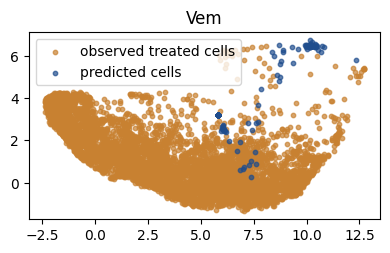

In [6]:

drug = 'Vem'
jfe_indices = [1, 6, 0, 5, 4, 7, 8, 2, 3, 19]

X_pre_combined = np.concatenate([X_pre_COLO858, X_pre_RVH421, X_pre_SKMEL19], axis=0)
X_post_combined = np.concatenate([X_post_COLO858, X_post_RVH421, X_post_SKMEL19], axis=0)


X_tr_pre = X_pre_combined
Y_tr_post = X_post_combined
X_te_pre = X_pre_WM902B
Y_te_post = X_post_WM902B

print(X_tr_pre.shape)
print(X_te_pre.shape)
print(Y_tr_post.shape)
print(Y_te_post.shape)
# Compute median heuristic gamma on training data
median_gamma = median_heuristic_gamma(X_tr_pre, Y_tr_post)
print("Median heuristic gamma:", median_gamma)


all_metrics = []
for run in range(10):
    print(f"**************** Run: {run} ****************")
    seed = 1234 + run
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    out = run_cellot_pair(X_tr_pre[:, jfe_indices], Y_tr_post[:, jfe_indices], X_te_pre[:, jfe_indices], Y_te_post[:, jfe_indices], n_epochs=1000)
    metrics = summarize_metrics(out["y_pred"], Y_te_post[:, jfe_indices], median_gamma)
    print(f"Run {run} metrics: {metrics}")
    all_metrics.append(metrics)

# Results summary
df = pd.DataFrame(all_metrics)
print(df.describe().T[['mean', 'std']].round(4))


from umap import UMAP
import matplotlib.pyplot as plt

source = Y_tr_post[:, jfe_indices]
target = Y_te_post[:, jfe_indices]
predicted = out.get('y_pred') 

# Instantiate UMAP
umap_model = UMAP(n_components=2, random_state=42)

all_sample_umap = umap_model.fit_transform(np.vstack([source, target]))
source_umap = umap_model.transform(source)
target_umap = umap_model.transform(target)
y_pred_umap = umap_model.transform(predicted)

fig, ax = plt.subplots(figsize=(4, 4))
# ax.scatter(source_umap[:, 0], source_umap[:, 1], s=10, alpha=0.7, label='train_post', color='C2')
ax.scatter(target_umap[:, 0], target_umap[:, 1], s=10, alpha=0.7, label='observed treated cells', color="#C88131")
ax.scatter(y_pred_umap[:, 0], y_pred_umap[:, 1], s=10, alpha=0.7, label='predicted cells', color="#1F4D8D")

ax.set_title(f'{drug}')
# ax.set_xlabel('UMAP 1')
# ax.set_ylabel('UMAP 2')
ax.set_aspect('equal', 'box')
# Add a legend to distinguish the points
ax.legend()
# Adjust layout
plt.tight_layout()
# Display the plot
plt.savefig(f"./plots/cellot_on_4i_drug_{drug}.png", dpi=300)

(11393, 20)
(520, 20)
(11393, 20)
(520, 20)


VERS torch=1.13.1+cu117 (CellOT), device=cuda


Median heuristic gamma: 0.05893605971644417
**************** Run: 0 ****************


[CellOT] epoch=0 f_loss=-4593324.0000 g_loss=5116263.0000 | train mmd=0.0942 | test_mmd=0.8483
[CellOT] epoch=50 f_loss=-772.6560 g_loss=415.4079 | train mmd=0.4161 | test_mmd=0.3699


[CellOT] epoch=100 f_loss=-295.1765 g_loss=325.0969 | train mmd=0.8443 | test_mmd=0.1828
[CellOT] epoch=150 f_loss=-460.8963 g_loss=540.1191 | train mmd=0.8273 | test_mmd=0.1597
[CellOT] epoch=200 f_loss=-650.2881 g_loss=786.9022 | train mmd=0.7694 | test_mmd=0.1190
[CellOT] epoch=250 f_loss=-804.7593 g_loss=816.7473 | train mmd=0.7535 | test_mmd=0.1328
[CellOT] epoch=300 f_loss=-2782.9841 g_loss=12164.5225 | train mmd=0.3833 | test_mmd=0.2021
[CellOT] epoch=350 f_loss=-2968.8596 g_loss=14942.9199 | train mmd=0.4784 | test_mmd=0.1290
[CellOT] epoch=400 f_loss=-6938.4253 g_loss=33326.4023 | train mmd=0.4225 | test_mmd=0.1226
[CellOT] epoch=450 f_loss=-9923.4189 g_loss=40167.3750 | train mmd=0.4777 | test_mmd=0.3665
[CellOT] epoch=500 f_loss=-7578.8662 g_loss=38325.4531 | train mmd=0.3850 | test_mmd=0.1082
[CellOT] epoch=550 f_loss=-8803.1680 g_loss=37666.8750 | train mmd=0.5423 | test_mmd=0.1210
[CellOT] epoch=600 f_loss=-4022.1440 g_loss=16706.6387 | train mmd=0.5583 | test_mmd=0.1081


...

[CellOT] epoch=0 f_loss=-3972224.5000 g_loss=4540668.5000 | train mmd=0.0942 | test_mmd=0.8483
[CellOT] epoch=50 f_loss=-769.4969 g_loss=226.8965 | train mmd=0.4149 | test_mmd=0.7414
[CellOT] epoch=100 f_loss=-282.5291 g_loss=400.0139 | train mmd=0.9283 | test_mmd=0.1929
[CellOT] epoch=150 f_loss=-594.7170 g_loss=640.9982 | train mmd=0.8554 | test_mmd=0.1043
[CellOT] epoch=200 f_loss=-747.4776 g_loss=788.4111 | train mmd=0.8111 | test_mmd=0.1719
[CellOT] epoch=250 f_loss=-856.0685 g_loss=1202.7117 | train mmd=0.7676 | test_mmd=0.1495
[CellOT] epoch=300 f_loss=-1283.9688 g_loss=1159.7991 | train mmd=0.6194 | test_mmd=0.0953
[CellOT] epoch=350 f_loss=-1156.1849 g_loss=2864.0828 | train mmd=0.4550 | test_mmd=0.1728
[CellOT] epoch=400 f_loss=-1151.7201 g_loss=2358.1304 | train mmd=0.5680 | test_mmd=0.1267
[CellOT] epoch=450 f_loss=-1414.9034 g_loss=1905.6211 | train mmd=0.6869 | test_mmd=0.0927
[CellOT] epoch=500 f_loss=-1565.0991 g_loss=2304.5750 | train mmd=0.7182 | test_mmd=0.0908
[Cell

Run 8 metrics: {'mmd2_gamma_median': 0.09104482755321985, 'mmd2_gamma_0.5': 0.29515753857570903, 'mmd2_gamma_1.0': 0.3599128490597099, 'wasserstein_distance': 1.6789655060619295, 'R2_feature_means': 0.776441091294655}
**************** Run: 9 ****************


[CellOT] epoch=0 f_loss=-2659757.5000 g_loss=3404708.0000 | train mmd=0.0942 | test_mmd=0.8483
[CellOT] epoch=50 f_loss=-568.2556 g_loss=376.5906 | train mmd=0.6114 | test_mmd=0.2632
[CellOT] epoch=100 f_loss=-216.0735 g_loss=342.1408 | train mmd=0.8951 | test_mmd=0.1799
[CellOT] epoch=150 f_loss=-471.3456 g_loss=573.5812 | train mmd=0.8103 | test_mmd=0.0919
[CellOT] epoch=200 f_loss=-681.5709 g_loss=739.5071 | train mmd=0.8056 | test_mmd=0.1547
[CellOT] epoch=250 f_loss=-7708.1641 g_loss=1188.7354 | train mmd=0.3893 | test_mmd=0.1507
[CellOT] epoch=300 f_loss=-1408.6021 g_loss=6558.7295 | train mmd=0.5724 | test_mmd=0.1269
[CellOT] epoch=350 f_loss=-10223.0488 g_loss=4279.6802 | train mmd=0.5648 | test_mmd=0.1586
[CellOT] epoch=400 f_loss=-63356.8438 g_loss=26022.1016 | train mmd=0.2175 | test_mmd=1.2573
[CellOT] epoch=450 f_loss=-22178.4219 g_loss=19285.3965 | train mmd=0.3837 | test_mmd=0.2707
[CellOT] epoch=500 f_loss=-18984.1543 g_loss=12871.4346 | train mmd=0.5185 | test_mmd=0.10

Run 9 metrics: {'mmd2_gamma_median': 0.09822969805156911, 'mmd2_gamma_0.5': 0.6022487076962353, 'mmd2_gamma_1.0': 0.8138445732854638, 'wasserstein_distance': 1.6444063920640204, 'R2_feature_means': 0.7363513211784986}
                        mean     std
mmd2_gamma_median     0.0994  0.0404
mmd2_gamma_0.5        0.3697  0.0880
mmd2_gamma_1.0        0.4739  0.1308
wasserstein_distance  1.6846  0.1978
R2_feature_means      0.7752  0.0766


/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


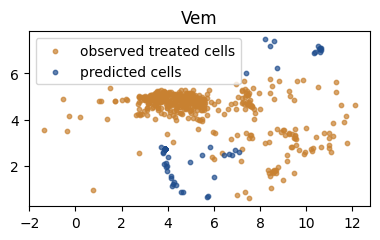

In [7]:


drug = 'Vem'
jfe_indices = [1, 6, 0, 5, 4, 7, 8, 2, 3, 19]

X_pre_combined = np.concatenate([X_pre_COLO858, X_pre_WM902B, X_pre_SKMEL19], axis=0)
X_post_combined = np.concatenate([X_post_COLO858, X_post_WM902B, X_post_SKMEL19], axis=0)


X_tr_pre = X_pre_combined
Y_tr_post = X_post_combined
X_te_pre = X_pre_RVH421
Y_te_post = X_post_RVH421

print(X_tr_pre.shape)
print(X_te_pre.shape)
print(Y_tr_post.shape)
print(Y_te_post.shape)
# Compute median heuristic gamma on training data
median_gamma = median_heuristic_gamma(X_tr_pre, Y_tr_post)
print("Median heuristic gamma:", median_gamma)


all_metrics = []
for run in range(10):
    print(f"**************** Run: {run} ****************")
    seed = 1234 + run
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    out = run_cellot_pair(X_tr_pre[:, jfe_indices], Y_tr_post[:, jfe_indices], X_te_pre[:, jfe_indices], Y_te_post[:, jfe_indices], n_epochs=1000)
    metrics = summarize_metrics(out["y_pred"], Y_te_post[:, jfe_indices], median_gamma)
    print(f"Run {run} metrics: {metrics}")
    all_metrics.append(metrics)

# Results summary
df = pd.DataFrame(all_metrics)
print(df.describe().T[['mean', 'std']].round(4))


from umap import UMAP
import matplotlib.pyplot as plt

source = Y_tr_post[:, jfe_indices]
target = Y_te_post[:, jfe_indices]
predicted = out.get('y_pred') 

# Instantiate UMAP
umap_model = UMAP(n_components=2, random_state=42)

all_sample_umap = umap_model.fit_transform(np.vstack([source, target]))
source_umap = umap_model.transform(source)
target_umap = umap_model.transform(target)
y_pred_umap = umap_model.transform(predicted)

fig, ax = plt.subplots(figsize=(4, 4))
# ax.scatter(source_umap[:, 0], source_umap[:, 1], s=10, alpha=0.7, label='train_post', color='C2')
ax.scatter(target_umap[:, 0], target_umap[:, 1], s=10, alpha=0.7, label='observed treated cells', color="#C88131")
ax.scatter(y_pred_umap[:, 0], y_pred_umap[:, 1], s=10, alpha=0.7, label='predicted cells', color="#1F4D8D")

ax.set_title(f'{drug}')
# ax.set_xlabel('UMAP 1')
# ax.set_ylabel('UMAP 2')
ax.set_aspect('equal', 'box')
# Add a legend to distinguish the points
ax.legend()
# Adjust layout
plt.tight_layout()
# Display the plot
plt.savefig(f"./plots/cellot_on_4i_drug_{drug}.png", dpi=300)

(9236, 20)
(2677, 20)
(9236, 20)
(2677, 20)


VERS torch=1.13.1+cu117 (CellOT), device=cuda


Median heuristic gamma: 0.05327606871702425
**************** Run: 0 ****************


[CellOT] epoch=0 f_loss=-3790900.7500 g_loss=4461129.0000 | train mmd=0.0947 | test_mmd=0.8153
[CellOT] epoch=50 f_loss=-372.8158 g_loss=313.4345 | train mmd=0.4957 | test_mmd=0.2266
[CellOT] epoch=100 f_loss=-333.7384 g_loss=426.1061 | train mmd=1.0197 | test_mmd=0.2310
[CellOT] epoch=150 f_loss=-606.2932 g_loss=950.8800 | train mmd=0.9982 | test_mmd=0.2382
[CellOT] epoch=200 f_loss=-864.0396 g_loss=873.5345 | train mmd=0.9506 | test_mmd=0.1543
[CellOT] epoch=250 f_loss=-964.8083 g_loss=1765.3960 | train mmd=0.7249 | test_mmd=0.2055
[CellOT] epoch=300 f_loss=-1228.5598 g_loss=1239.1714 | train mmd=0.8878 | test_mmd=0.2561
[CellOT] epoch=350 f_loss=-1248.7058 g_loss=3185.2007 | train mmd=0.5719 | test_mmd=0.1610
[CellOT] epoch=400 f_loss=-1615.4292 g_loss=1443.6674 | train mmd=0.7820 | test_mmd=0.1161
[CellOT] epoch=450 f_loss=-1729.4172 g_loss=1838.7654 | train mmd=0.8218 | test_mmd=0.0832
[CellOT] epoch=500 f_loss=-1776.9440 g_loss=2153.8667 | train mmd=0.7705 | test_mmd=0.0776
[Cell

Run 0 metrics: {'mmd2_gamma_median': 0.176886570573072, 'mmd2_gamma_0.5': 0.23027362137384627, 'mmd2_gamma_1.0': 0.21061216568398952, 'wasserstein_distance': 3.9782560867196683, 'R2_feature_means': 0.35311189563342804}
**************** Run: 1 ****************


...

[CellOT] epoch=0 f_loss=-3369023.0000 g_loss=3929952.5000 | train mmd=0.0947 | test_mmd=0.8153
[CellOT] epoch=50 f_loss=-1085.5096 g_loss=241.6942 | train mmd=0.4716 | test_mmd=0.6254
[CellOT] epoch=100 f_loss=-408.2881 g_loss=472.1466 | train mmd=0.9719 | test_mmd=0.2585
[CellOT] epoch=150 f_loss=-703.9635 g_loss=754.7882 | train mmd=1.0110 | test_mmd=0.2265
[CellOT] epoch=200 f_loss=-2007.1072 g_loss=973.2208 | train mmd=0.3433 | test_mmd=0.6261
[CellOT] epoch=250 f_loss=-1105.0322 g_loss=1073.9241 | train mmd=0.8288 | test_mmd=0.1597
[CellOT] epoch=300 f_loss=-1223.7786 g_loss=1535.8284 | train mmd=0.7353 | test_mmd=0.1098
[CellOT] epoch=350 f_loss=-1600.7548 g_loss=1822.4810 | train mmd=0.8802 | test_mmd=0.1375
[CellOT] epoch=400 f_loss=-1798.6040 g_loss=4526.2871 | train mmd=0.7339 | test_mmd=0.1612
[CellOT] epoch=450 f_loss=-1857.4575 g_loss=2219.3501 | train mmd=0.8299 | test_mmd=0.1311
[CellOT] epoch=500 f_loss=-3906.3140 g_loss=2481.5493 | train mmd=0.5643 | test_mmd=0.4735
[C

Run 8 metrics: {'mmd2_gamma_median': 0.0818137815595339, 'mmd2_gamma_0.5': 0.22901431466524758, 'mmd2_gamma_1.0': 0.25525871322522536, 'wasserstein_distance': 2.786135875675832, 'R2_feature_means': 0.8080810669300728}
**************** Run: 9 ****************


[CellOT] epoch=0 f_loss=-2647646.5000 g_loss=2850003.2500 | train mmd=0.0947 | test_mmd=0.8153
[CellOT] epoch=50 f_loss=151.1422 g_loss=207.6249 | train mmd=0.7217 | test_mmd=0.2666
[CellOT] epoch=100 f_loss=-320.1223 g_loss=426.0886 | train mmd=1.0210 | test_mmd=0.2702
[CellOT] epoch=150 f_loss=-604.1058 g_loss=655.8159 | train mmd=1.0260 | test_mmd=0.2388
[CellOT] epoch=200 f_loss=-937.1387 g_loss=871.0258 | train mmd=0.5961 | test_mmd=0.1252
[CellOT] epoch=250 f_loss=-969.7854 g_loss=939.1934 | train mmd=0.7962 | test_mmd=0.0753
[CellOT] epoch=300 f_loss=-2314.3848 g_loss=1179.4955 | train mmd=0.3032 | test_mmd=0.2756
[CellOT] epoch=350 f_loss=-2972.2354 g_loss=1366.7336 | train mmd=0.4784 | test_mmd=0.2695
[CellOT] epoch=400 f_loss=-1250.2854 g_loss=1497.9592 | train mmd=0.7394 | test_mmd=0.0885
[CellOT] epoch=450 f_loss=-1463.2136 g_loss=1722.3926 | train mmd=0.5629 | test_mmd=0.1795
[CellOT] epoch=500 f_loss=-1472.3333 g_loss=1966.9678 | train mmd=0.7315 | test_mmd=0.2436
[CellOT

Run 9 metrics: {'mmd2_gamma_median': 0.08689425571972587, 'mmd2_gamma_0.5': 0.20861374599177068, 'mmd2_gamma_1.0': 0.21291455442793358, 'wasserstein_distance': 2.099233470252963, 'R2_feature_means': 0.8228216590202974}
                        mean     std
mmd2_gamma_median     0.2286  0.1592
mmd2_gamma_0.5        0.2472  0.0560
mmd2_gamma_1.0        0.2131  0.0344
wasserstein_distance  3.8292  0.9192
R2_feature_means      0.6444  0.1574


/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


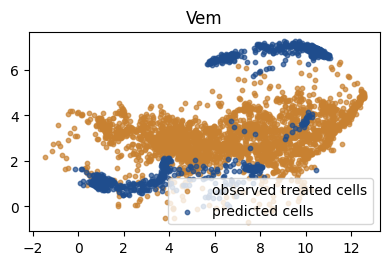

In [8]:



drug = 'Vem'
jfe_indices = [1, 6, 0, 5, 4, 7, 8, 2, 3, 19]

X_pre_combined = np.concatenate([X_pre_COLO858, X_pre_WM902B, X_pre_RVH421], axis=0)
X_post_combined = np.concatenate([X_post_COLO858, X_post_WM902B, X_post_RVH421], axis=0)


X_tr_pre = X_pre_combined
Y_tr_post = X_post_combined
X_te_pre = X_pre_SKMEL19
Y_te_post = X_post_SKMEL19


print(X_tr_pre.shape)
print(X_te_pre.shape)
print(Y_tr_post.shape)
print(Y_te_post.shape)
# Compute median heuristic gamma on training data
median_gamma = median_heuristic_gamma(X_tr_pre, Y_tr_post)
print("Median heuristic gamma:", median_gamma)


all_metrics = []
for run in range(10):
    print(f"**************** Run: {run} ****************")
    seed = 1234 + run
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    out = run_cellot_pair(X_tr_pre[:, jfe_indices], Y_tr_post[:, jfe_indices], X_te_pre[:, jfe_indices], Y_te_post[:, jfe_indices], n_epochs=1000)
    metrics = summarize_metrics(out["y_pred"], Y_te_post[:, jfe_indices], median_gamma)
    print(f"Run {run} metrics: {metrics}")
    all_metrics.append(metrics)

# Results summary
df = pd.DataFrame(all_metrics)
print(df.describe().T[['mean', 'std']].round(4))


from umap import UMAP
import matplotlib.pyplot as plt

source = Y_tr_post[:, jfe_indices]
target = Y_te_post[:, jfe_indices]
predicted = out.get('y_pred') 

# Instantiate UMAP
umap_model = UMAP(n_components=2, random_state=42)

all_sample_umap = umap_model.fit_transform(np.vstack([source, target]))
source_umap = umap_model.transform(source)
target_umap = umap_model.transform(target)
y_pred_umap = umap_model.transform(predicted)

fig, ax = plt.subplots(figsize=(4, 4))
# ax.scatter(source_umap[:, 0], source_umap[:, 1], s=10, alpha=0.7, label='train_post', color='C2')
ax.scatter(target_umap[:, 0], target_umap[:, 1], s=10, alpha=0.7, label='observed treated cells', color="#C88131")
ax.scatter(y_pred_umap[:, 0], y_pred_umap[:, 1], s=10, alpha=0.7, label='predicted cells', color="#1F4D8D")

ax.set_title(f'{drug}')
# ax.set_xlabel('UMAP 1')
# ax.set_ylabel('UMAP 2')
ax.set_aspect('equal', 'box')
# Add a legend to distinguish the points
ax.legend()
# Adjust layout
plt.tight_layout()
# Display the plot
plt.savefig(f"./plots/cellot_on_4i_drug_{drug}.png", dpi=300)